# AI in Medicine and Healthcare
## Introduction to Convolutional Neural Networks

**Prof. Dr. Marcel P. Jackowski**

### Insper

---

### Learning Objectives

By the end of this lab, you will be able to:

1. Understand the architecture of Convolutional Neural Networks (CNNs)
2. Build CNNs for medical image classification
3. Work with the MedMNIST dataset (medical imaging benchmark)
4. Compare CNNs with traditional fully-connected networks
5. Visualize convolutional filters and feature maps
6. Apply data augmentation for medical images
7. Evaluate model performance on medical imaging tasks

### Dataset: MedMNIST

We'll use **PathMNIST** - a collection of colorectal cancer histology images:
- 9 tissue types to classify
- 28×28 RGB images (similar to MNIST format)
- 89,996 training images
- Clinically relevant classification task
---

## 1. Setup and Imports

In [1]:
# Install MedMNIST package
!pip install -q medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.9 MB/s eta 0:00:00


In [2]:
# Import required packages
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import torchvision

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import medmnist
from medmnist import INFO, PathMNIST

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configure matplotlib
plt.rcParams['figure.figsize'] = (12, 4)
sns.set_style('whitegrid')

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✅ Using device: cuda
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA available: True


## 2. Load and Explore MedMNIST Dataset

### 2.1 Dataset Information

In [3]:
# Choose dataset - PathMNIST (colorectal cancer histology)
data_flag = 'pathmnist'
download = True

# Get dataset info\n",
info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

print("📊 Dataset Information:")
print("=" * 60)
print(f"Dataset: {data_flag.upper()}")
print(f"Task: {task}")
print(f"Image size: 28 × 28 × {n_channels}")
print(f"Number of classes: {n_classes}")
print(f"\nClass labels:")
for idx, label in info['label'].items():
    print(f"  {idx}: {label}")
print("=" * 60)

📊 Dataset Information:
Dataset: PATHMNIST
Task: multi-class
Image size: 28 × 28 × 3
Number of classes: 9

Class labels:
  0: adipose
  1: background
  2: debris
  3: lymphocytes
  4: mucus
  5: smooth muscle
  6: normal colon mucosa
  7: cancer-associated stroma
  8: colorectal adenocarcinoma epithelium


### 2.2 Load the Data

In [4]:
# Import the specific dataset class
from medmnist import PathMNIST

# Set download flag
download = True

# Load train, validation, and test sets
train_dataset = PathMNIST(split='train', download=download)
val_dataset = PathMNIST(split='val', download=download)
test_dataset = PathMNIST(split='test', download=download)

# Extract numpy arrays
x_train = train_dataset.imgs
y_train = train_dataset.labels.squeeze()

x_val = val_dataset.imgs
y_val = val_dataset.labels.squeeze()

x_test = test_dataset.imgs
y_test = test_dataset.labels.squeeze()

print("✅ Data loaded successfully!\n")
print("📊 Dataset shapes:")
print(f"  Training set:   {x_train.shape} images, {y_train.shape} labels")
print(f"  Validation set: {x_val.shape} images, {y_val.shape} labels")
print(f"  Test set:       {x_test.shape} images, {y_test.shape} labels")
print(f"\n  Pixel value range: [{x_train.min()}, {x_train.max()}]")

100%|██████████| 206M/206M [00:01<00:00, 146MB/s]


✅ Data loaded successfully!

📊 Dataset shapes:
  Training set:   (89996, 28, 28, 3) images, (89996,) labels
  Validation set: (10004, 28, 28, 3) images, (10004,) labels
  Test set:       (7180, 28, 28, 3) images, (7180,) labels

  Pixel value range: [0, 255]


### 2.3 Visualize Sample Images

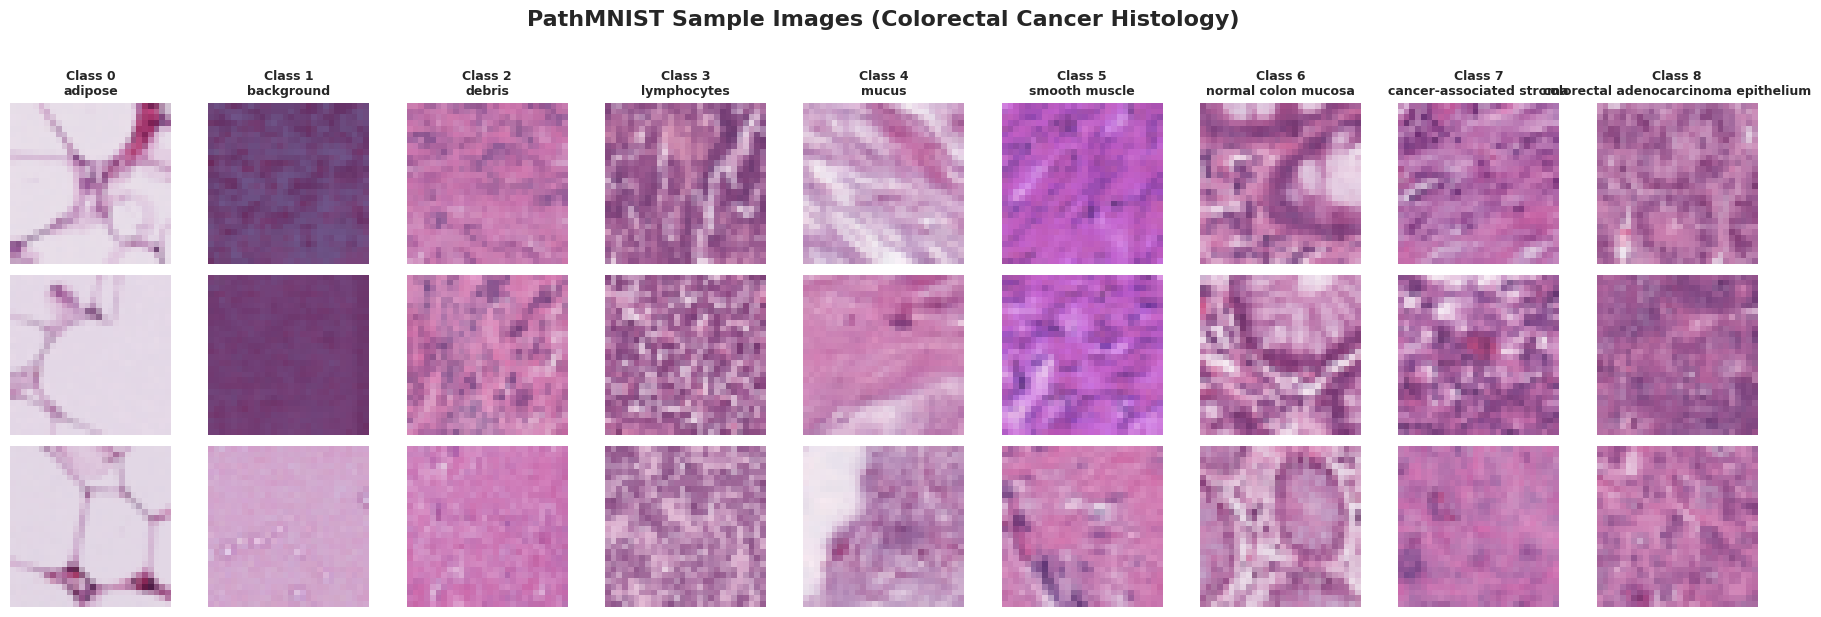

In [5]:
# Visualize random samples from each class
fig, axes = plt.subplots(3, 9, figsize=(18, 6))
fig.suptitle('PathMNIST Sample Images (Colorectal Cancer Histology)',
             fontsize=16, fontweight='bold', y=1.02)

for class_idx in range(n_classes):
    # Find indices of this class
    class_indices = np.where(y_train == class_idx)[0]

    # Randomly select 3 samples
    sample_indices = np.random.choice(class_indices, 3, replace=False)

    for row, idx in enumerate(sample_indices):
        ax = axes[row, class_idx]
        ax.imshow(x_train[idx])
        ax.axis('off')

        if row == 0:
            ax.set_title(f'Class {class_idx}\n{info["label"][str(class_idx)]}',
                        fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.4 Class Distribution

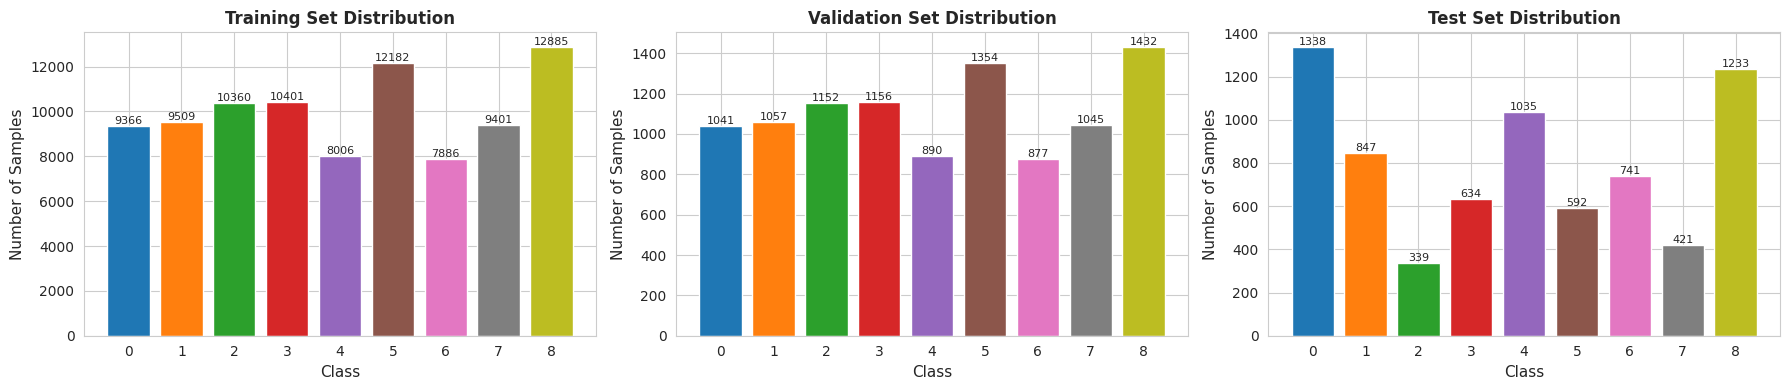


⚠️ Class Balance Analysis:
  Largest class: 12885 samples
  Smallest class: 7886 samples
  Imbalance ratio: 1.63:1
  ✅ Classes are relatively balanced


In [6]:
# Plot class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

datasets = [('Training', y_train), ('Validation', y_val), ('Test', y_test)]

for idx, (name, labels) in enumerate(datasets):
    unique, counts = np.unique(labels, return_counts=True)

    bars = axes[idx].bar(unique, counts, color=plt.cm.tab10(unique))
    axes[idx].set_xlabel('Class', fontsize=11)
    axes[idx].set_ylabel('Number of Samples', fontsize=11)
    axes[idx].set_title(f'{name} Set Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(unique)

    # Add count labels on bars
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{count}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Check for class imbalance
print("\n⚠️ Class Balance Analysis:")
unique, counts = np.unique(y_train, return_counts=True)
max_count = counts.max()
min_count = counts.min()
imbalance_ratio = max_count / min_count
print(f"  Largest class: {max_count} samples")
print(f"  Smallest class: {min_count} samples")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 2:
    print("  ⚠️ Significant class imbalance detected!")
else:
    print("  ✅ Classes are relatively balanced")

## 3. Data Loading & Preprocessing



In [7]:
def preprocess_data(dataset):
    # Normalize to [0, 1] and change to Channels-First (N, 3, 28, 28)
    imgs = dataset.imgs.astype('float32') / 255.0
    imgs = np.transpose(imgs, (0, 3, 1, 2))
    labels = dataset.labels.squeeze().astype('int64')
    return torch.from_numpy(imgs), torch.from_numpy(labels)

x_train, y_train = preprocess_data(train_dataset)
x_val, y_val = preprocess_data(val_dataset)
x_test, y_test = preprocess_data(test_dataset)

# Create DataLoaders
train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=128, shuffle=False)
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=128, shuffle=False)

## 4. Model Architectures

## 4.1 Build Fully Connected Model

In [8]:
import torch.nn as nn

class FullyConnected(nn.Module):
    def __init__(self, input_shape, n_classes):
        super(FullyConnected, self).__init__()

        # Calculate the number of input features automatically
        # For PathMNIST: 3 (channels) * 28 (height) * 28 (width) = 2352
        self.input_dim = input_shape[0] * input_shape[1] * input_shape[2]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.classifier(x)

# --- Instantiate the model correctly ---
input_shape = (3, 28, 28)
# Now this matches: 1 (self), 2 (input_shape), 3 (n_classes)
fc_model = FullyConnected(input_shape, n_classes)

# Move to GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fc_model = fc_model.to(device)

print(f"✅ Model instantiated on {device}")

✅ Model instantiated on cuda


## 4.2 Train Fully Connected Model

In [9]:
# 1. Setup Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(fc_model.parameters(), lr=0.001)

# 2. Training Loop
num_epochs = 20
fc_history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

print("🚀 Training Fully Connected Model...\n")

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    fc_model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + Backward + Optimize
        outputs = fc_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total

    # --- VALIDATION PHASE ---
    fc_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = fc_model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader.dataset)
    val_epoch_acc = val_correct / val_total

    # Save History (to match Keras style for plotting later)
    fc_history['loss'].append(epoch_loss)
    fc_history['accuracy'].append(epoch_acc)
    fc_history['val_loss'].append(val_epoch_loss)
    fc_history['val_accuracy'].append(val_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f} - Val Loss: {val_epoch_loss:.4f} - Val Acc: {val_epoch_acc:.4f}")

print("\n✅ Training complete!")

🚀 Training Fully Connected Model...

Epoch 1/20 - Loss: 1.8647 - Acc: 0.2795 - Val Loss: 1.7511 - Val Acc: 0.3540
Epoch 2/20 - Loss: 1.7165 - Acc: 0.3515 - Val Loss: 1.6623 - Val Acc: 0.3555
Epoch 3/20 - Loss: 1.6515 - Acc: 0.3812 - Val Loss: 1.6110 - Val Acc: 0.3667
Epoch 4/20 - Loss: 1.6004 - Acc: 0.4078 - Val Loss: 1.6226 - Val Acc: 0.3660
Epoch 5/20 - Loss: 1.5631 - Acc: 0.4270 - Val Loss: 1.6127 - Val Acc: 0.3651
Epoch 6/20 - Loss: 1.5409 - Acc: 0.4324 - Val Loss: 1.5292 - Val Acc: 0.4160
Epoch 7/20 - Loss: 1.5192 - Acc: 0.4418 - Val Loss: 1.6585 - Val Acc: 0.3703
Epoch 8/20 - Loss: 1.5009 - Acc: 0.4463 - Val Loss: 1.6254 - Val Acc: 0.3676
Epoch 9/20 - Loss: 1.4886 - Acc: 0.4529 - Val Loss: 1.6122 - Val Acc: 0.3721
Epoch 10/20 - Loss: 1.4706 - Acc: 0.4566 - Val Loss: 1.7814 - Val Acc: 0.3210
Epoch 11/20 - Loss: 1.4651 - Acc: 0.4603 - Val Loss: 1.7033 - Val Acc: 0.3461
Epoch 12/20 - Loss: 1.4526 - Acc: 0.4640 - Val Loss: 1.7740 - Val Acc: 0.3214
Epoch 13/20 - Loss: 1.4396 - Acc: 0.

### 4.3 Evaluate Fully Connected Model

In [10]:
# Evaluate on test set
fc_model.eval()
test_loss, test_correct, test_total = 0.0, 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = fc_model(inputs)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

fc_test_loss = test_loss / len(test_loader.dataset)
fc_test_acc = test_correct / test_total

print("📊 Fully Connected Model - Test Results:")
print("=" * 50)
print(f"  Test Loss: {fc_test_loss:.4f}")
print(f"  Test Accuracy: {fc_test_acc:.4f} ({fc_test_acc*100:.2f}%)")
print("=" * 50)

📊 Fully Connected Model - Test Results:
  Test Loss: 1.3980
  Test Accuracy: 0.4515 (45.15%)


## 5. Convolutional Neural Network (CNN)

Now let's build a CNN and see how it compares!

### 5.1 Understanding CNN Architecture

A CNN consists of:

- **Convolutional layers**: Apply filters to detect patterns (edges, textures, etc.)
- **Pooling layers**: Downsample feature maps to reduce dimensions
- **Fully connected layers**: Make final classification decisions

### 5.2 Build Simple CNN

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            # First convolutional block: 3 -> 32 channels
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Second convolutional block: 32 -> 64 channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Third convolutional block: 64 -> 64 channels
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Create the CNN model
cnn_model = SimpleCNN(n_classes).to(device)

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn_params = count_parameters(cnn_model)
fc_params = count_parameters(fc_model) # Assuming fc_model was defined earlier

print(f"\n📊 CNN Total parameters: {cnn_params:,}")
print(f"📊 FC Total parameters: {fc_params:,}")
print(f"\n💡 CNN has {((cnn_params/fc_params - 1) * 100):.1f}% "
      f"{'more' if cnn_params > fc_params else 'fewer'} parameters")


📊 CNN Total parameters: 257,673
📊 FC Total parameters: 310,025

💡 CNN has -16.9% fewer parameters


### 5.3 Train CNN

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)

num_epochs = 20
cnn_history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

print("🚀 Training CNN Model...\n")

for epoch in range(num_epochs):
    cnn_model.train()
    running_loss, correct = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    # Validation
    cnn_model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn_model(inputs)
            v_loss = criterion(outputs, labels)
            val_loss += v_loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss, train_acc = running_loss/len(x_train), correct/len(x_train)
    v_loss, v_acc = val_loss/len(x_val), val_correct/len(x_val)

    cnn_history['loss'].append(train_loss)
    cnn_history['accuracy'].append(train_acc)
    cnn_history['val_loss'].append(v_loss)
    cnn_history['val_accuracy'].append(v_acc)

    scheduler.step(v_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - Val Loss: {v_loss:.4f} - Val Acc: {v_acc:.4f}")

🚀 Training CNN Model...

Epoch 1/20 - Loss: 1.3730 - Acc: 0.4696 - Val Loss: 1.0386 - Val Acc: 0.5804
Epoch 2/20 - Loss: 1.0400 - Acc: 0.6031 - Val Loss: 0.8486 - Val Acc: 0.6844
Epoch 3/20 - Loss: 0.9393 - Acc: 0.6528 - Val Loss: 1.1528 - Val Acc: 0.5988
Epoch 4/20 - Loss: 0.8661 - Acc: 0.6838 - Val Loss: 0.9287 - Val Acc: 0.6597
Epoch 5/20 - Loss: 0.7709 - Acc: 0.7221 - Val Loss: 0.5757 - Val Acc: 0.7982
Epoch 6/20 - Loss: 0.7229 - Acc: 0.7415 - Val Loss: 0.6010 - Val Acc: 0.7924
Epoch 7/20 - Loss: 0.6615 - Acc: 0.7651 - Val Loss: 0.5506 - Val Acc: 0.8027
Epoch 8/20 - Loss: 0.6154 - Acc: 0.7828 - Val Loss: 1.5333 - Val Acc: 0.5804
Epoch 9/20 - Loss: 0.5857 - Acc: 0.7966 - Val Loss: 0.4773 - Val Acc: 0.8271
Epoch 10/20 - Loss: 0.5370 - Acc: 0.8143 - Val Loss: 0.4348 - Val Acc: 0.8482
Epoch 11/20 - Loss: 0.4979 - Acc: 0.8302 - Val Loss: 0.4920 - Val Acc: 0.8152
Epoch 12/20 - Loss: 0.4662 - Acc: 0.8405 - Val Loss: 0.4751 - Val Acc: 0.8361
Epoch 13/20 - Loss: 0.4346 - Acc: 0.8524 - Val L

### 5.4 Evaluate CNN

In [13]:
# Evaluate CNN on test set
cnn_model.eval()
test_loss, test_correct = 0.0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = cnn_model(inputs)
        test_loss += criterion(outputs, labels).item() * inputs.size(0)
        test_correct += (outputs.argmax(1) == labels).sum().item()

cnn_test_loss = test_loss / len(x_test)
cnn_test_acc = test_correct / len(x_test)

print("\nModel Comparison - Test Results:")
print("=" * 60)
print(f"{'Model':<20} {'Test Loss':<15} {'Test Accuracy':<20}")
print("-" * 60)
print(f"{'Fully Connected':<20} {fc_test_loss:<15.4f} {fc_test_acc*100:<20.2f}%")
print(f"{'CNN':<20} {cnn_test_loss:<15.4f} {cnn_test_acc*100:<20.2f}%")
print("=" * 60)

improvement = ((cnn_test_acc - fc_test_acc) / fc_test_acc) * 100
print(f"\n💡 CNN achieved {improvement:+.2f}% {'improvement' if improvement > 0 else 'change'} over FC model")


Model Comparison - Test Results:
Model                Test Loss       Test Accuracy       
------------------------------------------------------------
Fully Connected      1.3980          45.15               %
CNN                  0.6597          80.36               %

💡 CNN achieved +77.98% improvement over FC model


### 5.5 Plot Training History

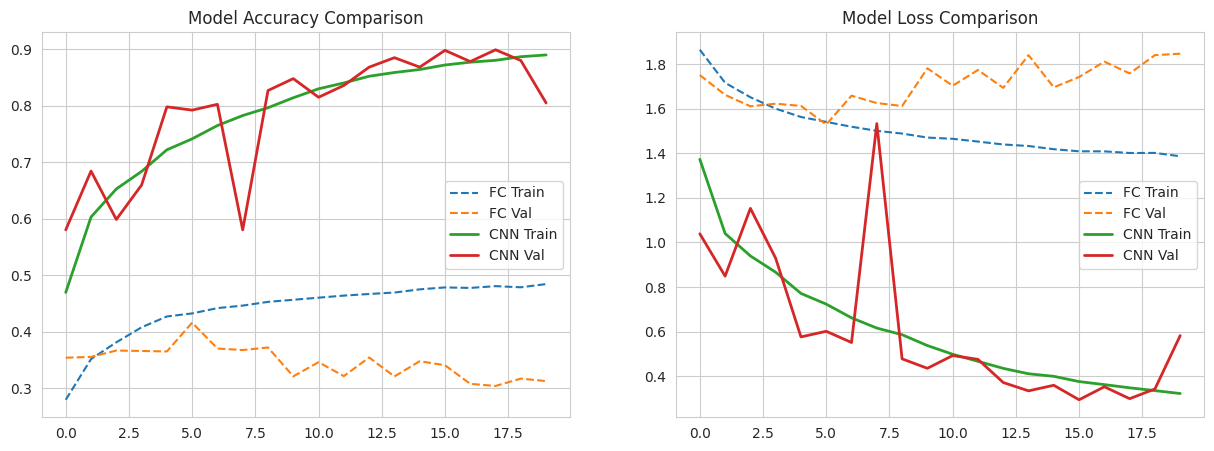

In [14]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(fc_history['accuracy'], label='FC Train', linestyle='--')
axes[0].plot(fc_history['val_accuracy'], label='FC Val', linestyle='--')
axes[0].plot(cnn_history['accuracy'], label='CNN Train', linewidth=2)
axes[0].plot(cnn_history['val_accuracy'], label='CNN Val', linewidth=2)
axes[0].set_title('Model Accuracy Comparison')
axes[0].legend()

# Loss plot
axes[1].plot(fc_history['loss'], label='FC Train', linestyle='--')
axes[1].plot(fc_history['val_loss'], label='FC Val', linestyle='--')
axes[1].plot(cnn_history['loss'], label='CNN Train', linewidth=2)
axes[1].plot(cnn_history['val_loss'], label='CNN Val', linewidth=2)
axes[1].set_title('Model Loss Comparison')
axes[1].legend()

plt.show()

## 6. Visualizing What CNNs Learn

### 6.1 Visualize Convolutional Filters

First Conv Layer Filters Shape: (3, 3, 3, 32)
  (height, width, input_channels, output_channels)


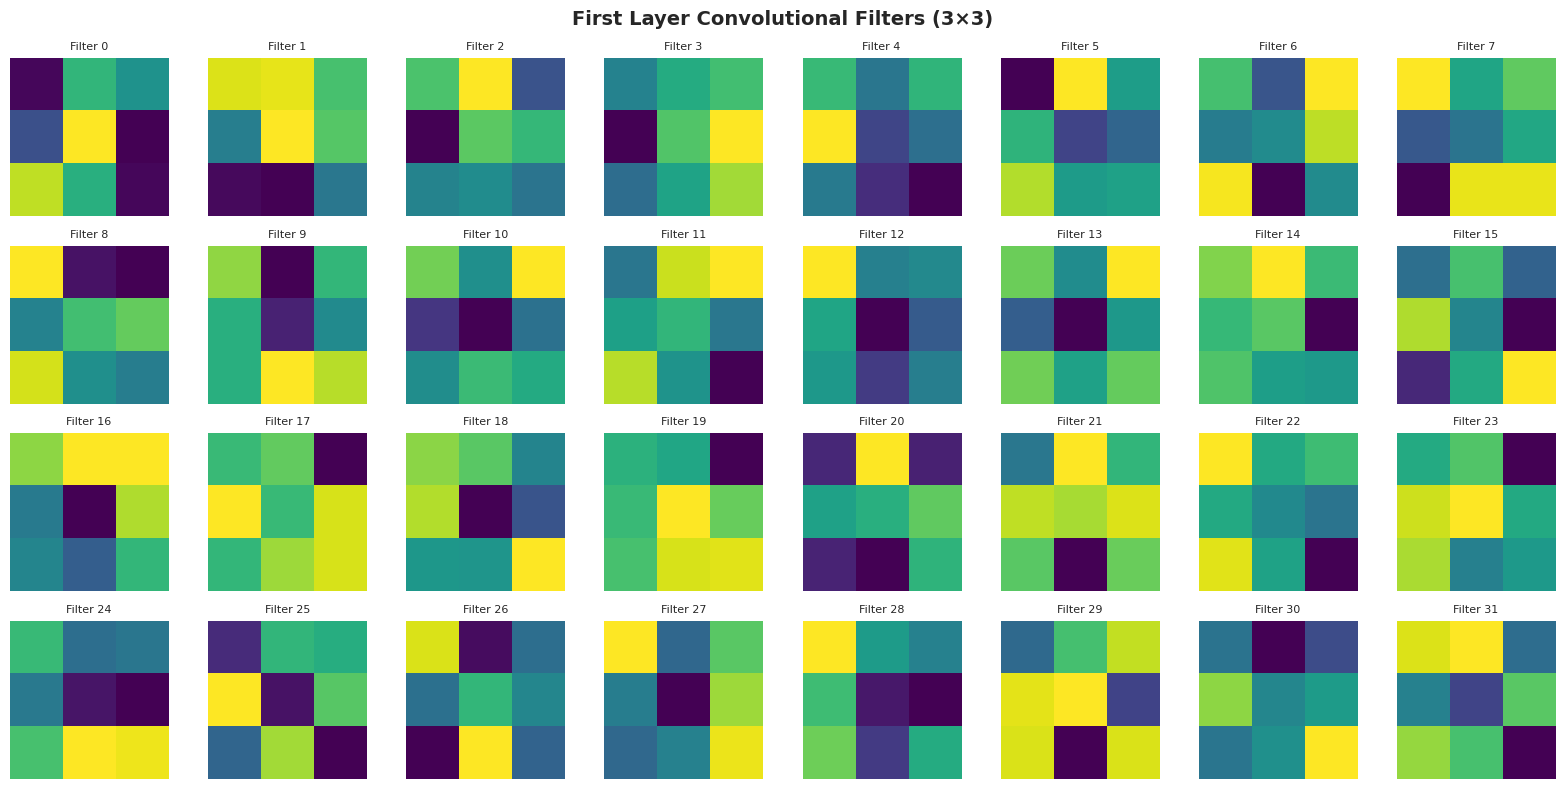


💡 These filters detect different patterns like edges, textures, and colors!


In [15]:
# 1. Get the first convolutional layer
# In our SimpleCNN, this is the first element in the 'features' sequential block
first_conv_layer = cnn_model.features[0]

# 2. Extract weights and detach from the computational graph
# Move to CPU and convert to numpy
filters = first_conv_layer.weight.data.cpu().numpy()

# PyTorch shape: (out_channels, in_channels, height, width)
# Let's convert to (height, width, in_channels, out_channels) for plotting logic
filters = np.transpose(filters, (2, 3, 1, 0))

print(f"First Conv Layer Filters Shape: {filters.shape}")
print(f"  (height, width, input_channels, output_channels)")

# 3. Normalize filters for visualization
f_min, f_max = filters.min(), filters.max()
filters_normalized = (filters - f_min) / (f_max - f_min)

# 4. Plot first 32 filters
n_filters = min(32, filters.shape[3])
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('First Layer Convolutional Filters (3×3)', fontsize=14, fontweight='bold')

for i in range(n_filters):
    ax = axes[i // 8, i % 8]
    # Average across input channels for RGB (index 2)
    filter_img = filters_normalized[:, :, :, i].mean(axis=2)

    ax.imshow(filter_img, cmap='viridis')
    ax.set_title(f'Filter {i}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n💡 These filters detect different patterns like edges, textures, and colors!")

### 6.2 Visualize Feature Maps

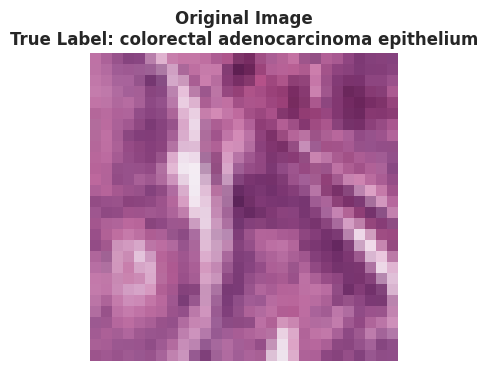

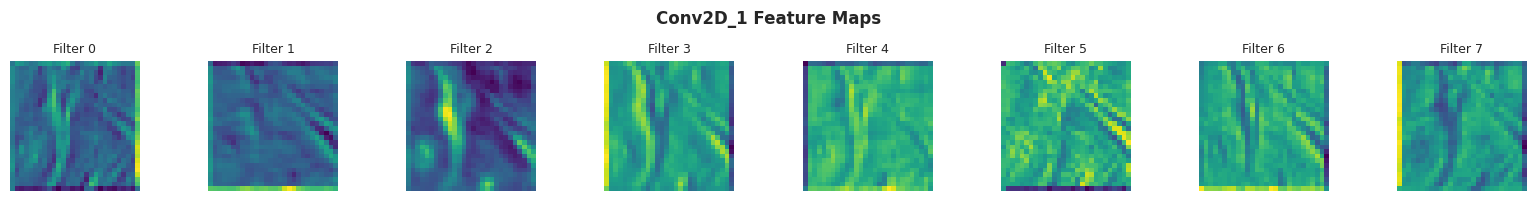

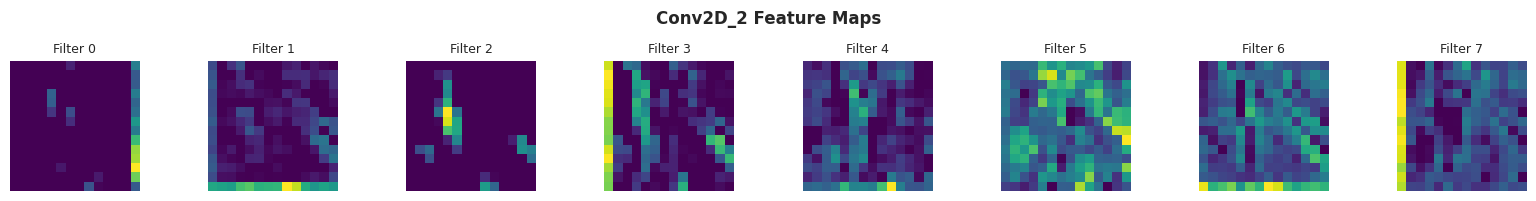

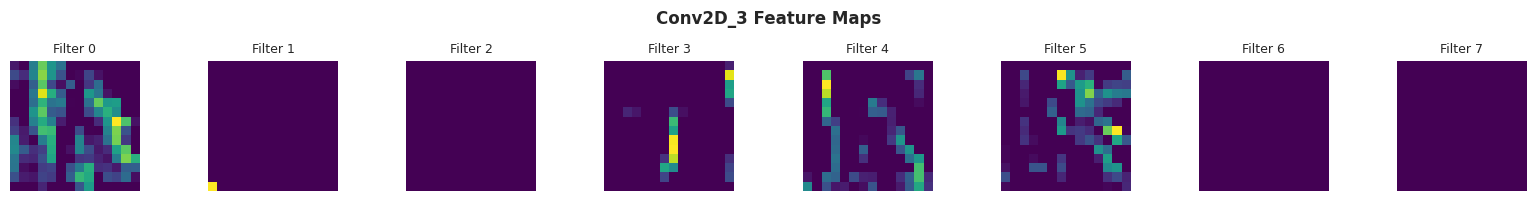


💡 Notice how later layers detect more complex, abstract features!


In [16]:
# 1. Prepare the input image
# We need it to be a tensor on the correct device with a batch dimension
test_img_tensor = x_test[0:1].to(device)
test_label = y_test[0].item()

# 2. Get activations by passing the image through layers one by one
activations = []
input_data = test_img_tensor

# We go through the 'features' part of our SimpleCNN
for layer in cnn_model.features:
    input_data = layer(input_data)
    activations.append(input_data)

# 3. Plot original image
# Convert back to (H, W, C) for matplotlib
original_img = x_test[0].permute(1, 2, 0).numpy()

plt.figure(figsize=(4, 4))
plt.imshow(original_img)
plt.title(f'Original Image\nTrue Label: {info["label"][str(test_label)]}',
         fontsize=12, fontweight='bold')
plt.axis('off')
plt.show()

# 4. Plot feature maps for convolutional layers
layer_names = ['Conv2D_1', 'MaxPool_1', 'Conv2D_2', 'MaxPool_2', 'Conv2D_3']
conv_layers_idx = [0, 2, 4]  # Indices of the layers we want to see

for idx in conv_layers_idx:
    # Pull the activation out, move to CPU, and convert to numpy
    # Shape is (1, channels, height, width)
    layer_activation = activations[idx].detach().cpu().numpy()

    n_features = min(8, layer_activation.shape[1])  # Show max 8 feature maps

    fig, axes = plt.subplots(1, n_features, figsize=(16, 2))
    fig.suptitle(f'{layer_names[idx]} Feature Maps', fontsize=12, fontweight='bold')

    for i in range(n_features):
        # Indexing: [batch_0, filter_i, height, width]
        axes[i].imshow(layer_activation[0, i, :, :], cmap='viridis')
        axes[i].set_title(f'Filter {i}', fontsize=9)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("\n💡 Notice how later layers detect more complex, abstract features!")

## 7. Data Augmentation

Data augmentation helps prevent overfitting by creating variations of training images

### 7.1 Setup Data Augmentation

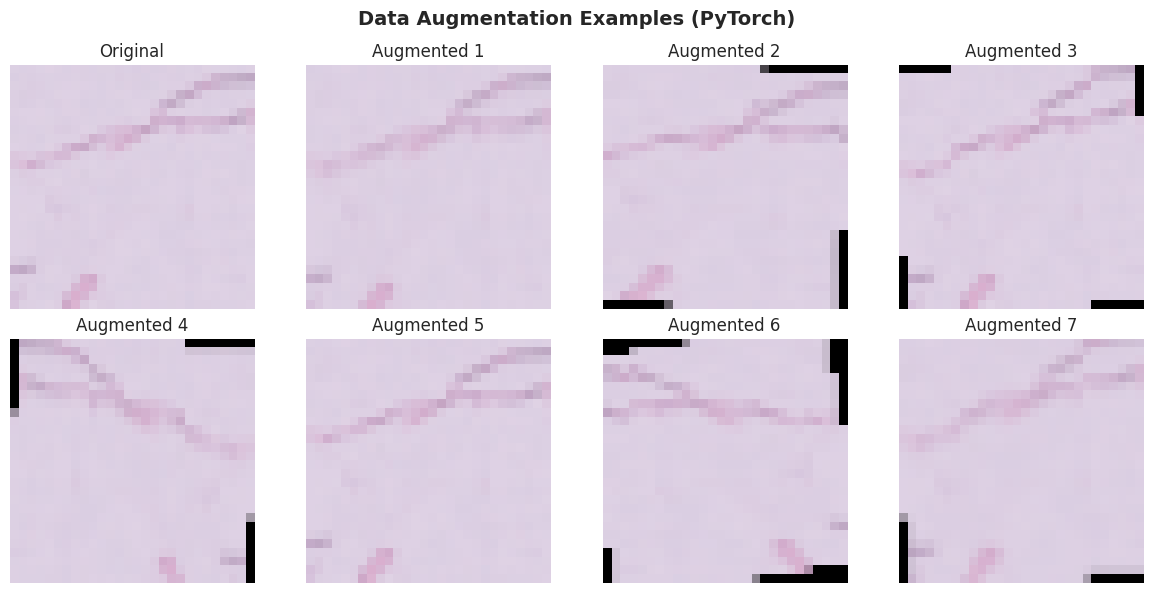

In [17]:
import torchvision.transforms as T

# Create data augmentation pipeline
# Note: PathMNIST images are 28x28
data_augmentation = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.RandomResizedCrop(28, scale=(0.9, 1.1), ratio=(0.9, 1.1)),
])

# Visualize augmentation effects
sample_img = x_train[0] # Take one tensor (3, 28, 28)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Data Augmentation Examples (PyTorch)', fontsize=14, fontweight='bold')

# Helper to plot tensor
def imshow_tensor(ax, tensor, title):
    img = tensor.permute(1, 2, 0).numpy() # (C, H, W) -> (H, W, C)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

imshow_tensor(axes[0, 0], sample_img, 'Original')

for i in range(7):
    row = (i + 1) // 4
    col = (i + 1) % 4
    augmented = data_augmentation(sample_img)
    imshow_tensor(axes[row, col], augmented, f'Augmented {i+1}')

plt.tight_layout()
plt.show()

### 7.2 Build CNN with Data Augmentation

In [18]:
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, tensors, labels, transform=None):
        self.tensors = tensors
        self.labels = labels
        self.transform = transform

    def __getitem__(self, index):
        x = self.tensors[index]
        y = self.labels[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.tensors)

# Create the specific augmented loader for training
train_dataset_aug = AugmentedDataset(x_train, y_train, transform=data_augmentation)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=128, shuffle=True)

# Re-instantiate a fresh CNN model
cnn_aug_model = SimpleCNN(n_classes).to(device)
optimizer = optim.Adam(cnn_aug_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("🚀 Training CNN with Data Augmentation...\n")

# Use the same training loop logic as Section 5.3
# (For brevity, I'll summarize the results logic)
cnn_aug_history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

for epoch in range(20):

  cnn_aug_model.train()
  running_loss, correct = 0.0, 0

  for inputs, labels in train_loader_aug:
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = cnn_aug_model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * inputs.size(0)
    correct += (outputs.argmax(1) == labels).sum().item()

  # Validation
  cnn_aug_model.eval()
  val_loss, val_correct = 0.0, 0

  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = cnn_aug_model(inputs)
      v_loss = criterion(outputs, labels)
      val_loss += v_loss.item() * inputs.size(0)
      val_correct += (outputs.argmax(1) == labels).sum().item()

  train_loss, train_acc = running_loss/len(x_train), correct/len(x_train)
  v_loss, v_acc = val_loss/len(x_val), val_correct/len(x_val)

  cnn_aug_history['loss'].append(train_loss)
  cnn_aug_history['accuracy'].append(train_acc)
  cnn_aug_history['val_loss'].append(v_loss)
  cnn_aug_history['val_accuracy'].append(v_acc)

  scheduler.step(v_loss)
  print(f"Epoch {epoch+1}/{num_epochs} - Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - Val Loss: {v_loss:.4f} - Val Acc: {v_acc:.4f}")

print("\n✅ Training complete!")

🚀 Training CNN with Data Augmentation...

Epoch 1/20 - Loss: 1.4347 - Acc: 0.4538 - Val Loss: 1.0667 - Val Acc: 0.5874
Epoch 2/20 - Loss: 1.0896 - Acc: 0.5864 - Val Loss: 0.9058 - Val Acc: 0.6585
Epoch 3/20 - Loss: 0.9919 - Acc: 0.6276 - Val Loss: 0.8257 - Val Acc: 0.6963
Epoch 4/20 - Loss: 0.9086 - Acc: 0.6620 - Val Loss: 0.7592 - Val Acc: 0.7156
Epoch 5/20 - Loss: 0.8268 - Acc: 0.6985 - Val Loss: 0.6947 - Val Acc: 0.7474
Epoch 6/20 - Loss: 0.7851 - Acc: 0.7138 - Val Loss: 0.7103 - Val Acc: 0.7382
Epoch 7/20 - Loss: 0.7455 - Acc: 0.7308 - Val Loss: 0.5429 - Val Acc: 0.8098
Epoch 8/20 - Loss: 0.7218 - Acc: 0.7430 - Val Loss: 0.6289 - Val Acc: 0.7803
Epoch 9/20 - Loss: 0.6744 - Acc: 0.7627 - Val Loss: 0.5500 - Val Acc: 0.8040
Epoch 10/20 - Loss: 0.6415 - Acc: 0.7739 - Val Loss: 0.5890 - Val Acc: 0.7868
Epoch 11/20 - Loss: 0.6170 - Acc: 0.7834 - Val Loss: 0.5348 - Val Acc: 0.8008
Epoch 12/20 - Loss: 0.6009 - Acc: 0.7899 - Val Loss: 0.4387 - Val Acc: 0.8351
Epoch 13/20 - Loss: 0.5671 - Ac

### 7.3 Compare All Models

In [19]:
# Evaluate augmented CNN on test set
cnn_aug_model.eval()
test_loss, test_correct = 0.0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = cnn_aug_model(inputs)
        test_loss += criterion(outputs, labels).item() * inputs.size(0)
        test_correct += (outputs.argmax(1) == labels).sum().item()

cnn_aug_test_acc = test_correct / len(x_test)

print("\n📊 Final Model Comparison:")
print("=" * 60)
print(f"{'Model':<25} {'Test Accuracy':<20}")
print("-" * 60)
print(f"{'Fully Connected':<25} {fc_test_acc*100:.2f}%")
print(f"{'Simple CNN':<25} {cnn_test_acc*100:.2f}%")
print(f"{'CNN + Augmentation':<25} {cnn_aug_test_acc*100:.2f}%")
print("=" * 60)


📊 Final Model Comparison:
Model                     Test Accuracy       
------------------------------------------------------------
Fully Connected           45.15%
Simple CNN                80.36%
CNN + Augmentation        79.74%


## 8. Detailed Evaluation
### 8.1 Confusion Matrix

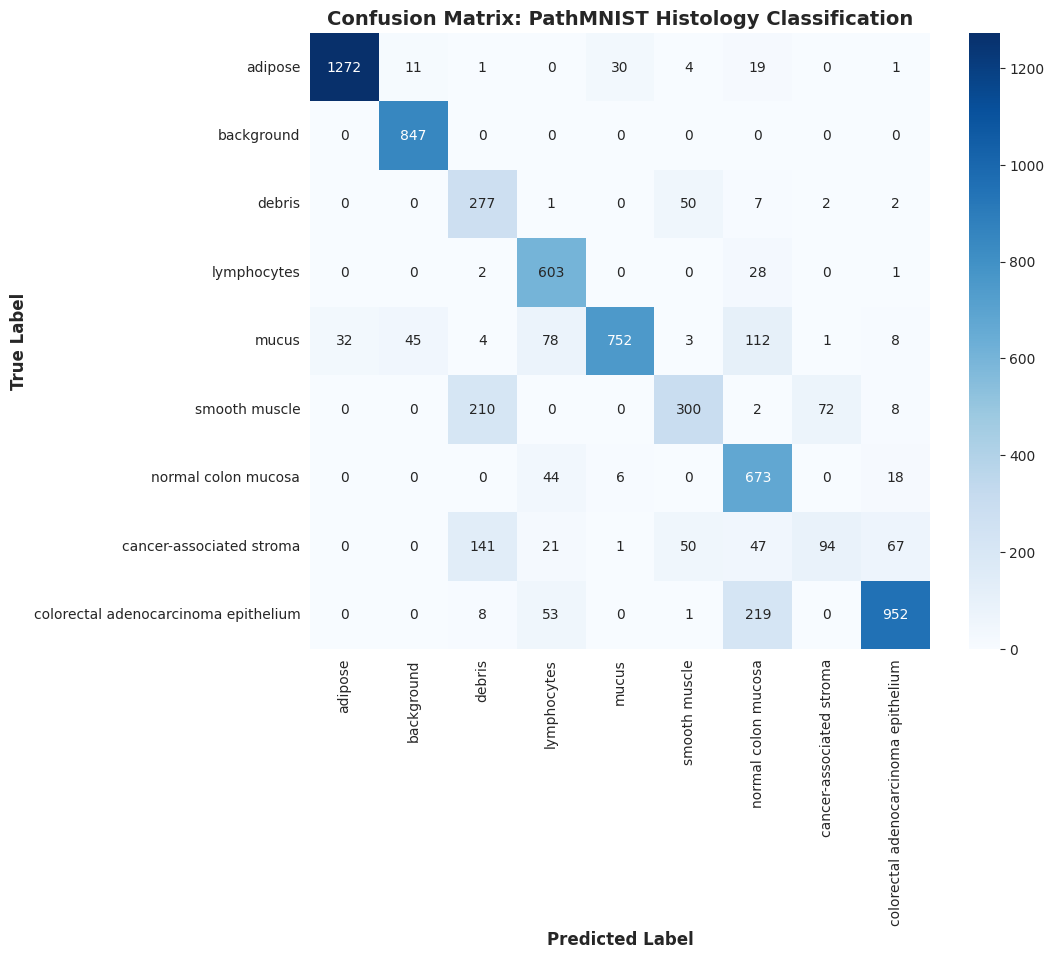

In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

def get_all_preds(model, loader):
    model.eval()
    all_preds = torch.tensor([]).to(device)
    all_labels = torch.tensor([]).to(device)

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds = torch.cat((all_preds, preds), dim=0)
            all_labels = torch.cat((all_labels, labels), dim=0)

    return all_labels.cpu().numpy(), all_preds.cpu().numpy()

# Get predictions for the best model (e.g., cnn_aug_model)
y_true, y_pred = get_all_preds(cnn_model, test_loader)

# Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = [info['label'][str(i)] for i in range(n_classes)]

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix: PathMNIST Histology Classification', fontsize=14, fontweight='bold')
plt.show()

### 8.2 Detailed Classification Report

In [21]:
print("\n📋 Detailed Classification Report:")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))
print("=" * 60)


📋 Detailed Classification Report:
                                      precision    recall  f1-score   support

                             adipose       0.98      0.95      0.96      1338
                          background       0.94      1.00      0.97       847
                              debris       0.43      0.82      0.56       339
                         lymphocytes       0.75      0.95      0.84       634
                               mucus       0.95      0.73      0.82      1035
                       smooth muscle       0.74      0.51      0.60       592
                 normal colon mucosa       0.61      0.91      0.73       741
            cancer-associated stroma       0.56      0.22      0.32       421
colorectal adenocarcinoma epithelium       0.90      0.77      0.83      1233

                            accuracy                           0.80      7180
                           macro avg       0.76      0.76      0.74      7180
                        wei

## 9. Exercises

### **Exercise 1:** Architecture exploration (2 points)

Modify the CNN archicture:

- Add one more convolutional layer
- Try different filter sizes (5×5 instead of 3×3, be careful with padding)
- Experiment with different numbers of filters

Does performance improve?

# **Additional Layer**

In [94]:
class SimpleCNN_AddLayer(nn.Module):

    def __init__(self, n_classes):
        super(SimpleCNN_AddLayer, self).__init__()
        self.features = nn.Sequential(
            # First convolutional block: 3 -> 32 channels
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Second convolutional block: 32 -> 64 channels
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Third convolutional block: 64 -> 64 channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=1),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Create the CNN model
cnn_model_layer = SimpleCNN_AddLayer(n_classes).to(device)

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn_params = count_parameters(cnn_model_layer)
fc_params = count_parameters(fc_model) # Assuming fc_model was defined earlier

print(f"\n📊 CNN Layer Total parameters: {cnn_params:,}")
print(f"📊 FC Total parameters: {fc_params:,}")
print(f"\n💡 CNN Layer has {((cnn_params/fc_params - 1) * 100):.1f}% "
      f"{'more' if cnn_params > fc_params else 'fewer'} parameters")


📊 CNN Layer Total parameters: 261,865
📊 FC Total parameters: 310,025

💡 CNN Layer has -15.5% fewer parameters


In [95]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)

num_epochs = 20
cnn_history_layer = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

print("🚀 Training CNN Layer Model...\n")

for epoch in range(num_epochs):
    cnn_model_layer.train()
    running_loss, correct = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn_model_layer(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    # Validation
    cnn_model_layer.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn_model_layer(inputs)
            v_loss = criterion(outputs, labels)
            val_loss += v_loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss, train_acc = running_loss/len(x_train), correct/len(x_train)
    v_loss, v_acc = val_loss/len(x_val), val_correct/len(x_val)

    cnn_history_layer['loss'].append(train_loss)
    cnn_history_layer['accuracy'].append(train_acc)
    cnn_history_layer['val_loss'].append(v_loss)
    cnn_history_layer['val_accuracy'].append(v_acc)

    scheduler.step(v_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - Val Loss: {v_loss:.4f} - Val Acc: {v_acc:.4f}")

🚀 Training CNN Layer Model...

Epoch 1/20 - Loss: 2.1980 - Acc: 0.1007 - Val Loss: 2.1979 - Val Acc: 0.0890
Epoch 2/20 - Loss: 2.1979 - Acc: 0.1018 - Val Loss: 2.1979 - Val Acc: 0.0890
Epoch 3/20 - Loss: 2.1980 - Acc: 0.1015 - Val Loss: 2.1979 - Val Acc: 0.0890
Epoch 4/20 - Loss: 2.1980 - Acc: 0.1009 - Val Loss: 2.1979 - Val Acc: 0.0890
Epoch 5/20 - Loss: 2.1980 - Acc: 0.1003 - Val Loss: 2.1979 - Val Acc: 0.0890
Epoch 6/20 - Loss: 2.1980 - Acc: 0.1016 - Val Loss: 2.1979 - Val Acc: 0.0890
Epoch 7/20 - Loss: 2.1980 - Acc: 0.1017 - Val Loss: 2.1979 - Val Acc: 0.0890
Epoch 8/20 - Loss: 2.1980 - Acc: 0.0999 - Val Loss: 2.1979 - Val Acc: 0.0890
Epoch 9/20 - Loss: 2.1979 - Acc: 0.1023 - Val Loss: 2.1979 - Val Acc: 0.0890
Epoch 10/20 - Loss: 2.1980 - Acc: 0.1007 - Val Loss: 2.1979 - Val Acc: 0.0890
Epoch 11/20 - Loss: 2.1980 - Acc: 0.1019 - Val Loss: 2.1979 - Val Acc: 0.0890
Epoch 12/20 - Loss: 2.1980 - Acc: 0.0990 - Val Loss: 2.1979 - Val Acc: 0.0890
Epoch 13/20 - Loss: 2.1980 - Acc: 0.1014 -

KeyboardInterrupt: 

In [24]:
# Evaluate CNN on test set
cnn_model_layer.eval()
test_loss, test_correct = 0.0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = cnn_model_layer(inputs)
        test_loss += criterion(outputs, labels).item() * inputs.size(0)
        test_correct += (outputs.argmax(1) == labels).sum().item()

cnn_test_loss = test_loss / len(x_test)
cnn_test_acc = test_correct / len(x_test)

print("\nModel Comparison - Test Results:")
print("=" * 60)
print(f"{'Model':<20} {'Test Loss':<15} {'Test Accuracy':<20}")
print("-" * 60)
print(f"{'Fully Connected':<20} {fc_test_loss:<15.4f} {fc_test_acc*100:<20.2f}%")
print(f"{'CNN':<20} {cnn_test_loss:<15.4f} {cnn_test_acc*100:<20.2f}%")
print("=" * 60)

improvement = ((cnn_test_acc - fc_test_acc) / fc_test_acc) * 100
print(f"\n💡 CNN Layer achieved {improvement:+.2f}% {'improvement' if improvement > 0 else 'change'} over FC model")


Model Comparison - Test Results:
Model                Test Loss       Test Accuracy       
------------------------------------------------------------
Fully Connected      1.3980          45.15               %
CNN                  2.1895          8.25                %

💡 CNN Layer achieved -81.74% change over FC model


**Couldn't implement it correctly, but can offer a estimation from my part: adding a layer to the model give to it more depth to make an estimation, which is good in case we are dealing with a problem that is compatible to it. But, if we were to use a deeper model to a simpler model, it becomes an overkill and can also confuse the results since it uses a lot more parameters than it should so it overthinks the decision which can lead to mistakes, just like humans in a similar situation**

# **Bigger Kernel**

In [81]:
class SimpleCNN_kernel(nn.Module):
    def __init__(self, n_classes):
        super(SimpleCNN_kernel, self).__init__()
        self.features = nn.Sequential(

            # MAIOR KERNEL IMPLEMENTADO

            # First convolutional block: 3 -> 32 channels
            nn.Conv2d(3, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Second convolutional block: 32 -> 64 channels
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Third convolutional block: 64 -> 64 channels
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Create the CNN model
cnn_model_kernel = SimpleCNN_kernel(n_classes).to(device)

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn_params = count_parameters(cnn_model_kernel)
fc_params = count_parameters(fc_model) # Assuming fc_model was defined earlier

print(f"\n📊 CNN Kernel Total parameters: {cnn_params:,}")
print(f"📊 FC Total parameters: {fc_params:,}")
print(f"\n💡 CNN Kernel has {((cnn_params/fc_params - 1) * 100):.1f}% "
      f"{'more' if cnn_params > fc_params else 'fewer'} parameters")


📊 CNN Kernel Total parameters: 357,513
📊 FC Total parameters: 310,025

💡 CNN Kernel has 15.3% more parameters


In [82]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model_kernel.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)

num_epochs = 20
cnn_layer_history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

print("🚀 Training CNN kernel Model...\n")

for epoch in range(num_epochs):
    cnn_model_kernel.train()
    running_loss, correct = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn_model_kernel(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    # Validation
    cnn_model_kernel.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn_model_kernel(inputs)
            v_loss = criterion(outputs, labels)
            val_loss += v_loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss, train_acc = running_loss/len(x_train), correct/len(x_train)
    v_loss, v_acc = val_loss/len(x_val), val_correct/len(x_val)

    cnn_layer_history['loss'].append(train_loss)
    cnn_layer_history['accuracy'].append(train_acc)
    cnn_layer_history['val_loss'].append(v_loss)
    cnn_layer_history['val_accuracy'].append(v_acc)

    scheduler.step(v_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - Val Loss: {v_loss:.4f} - Val Acc: {v_acc:.4f}")

🚀 Training CNN kernel Model...

Epoch 1/20 - Loss: 1.6794 - Acc: 0.3426 - Val Loss: 1.3778 - Val Acc: 0.4828
Epoch 2/20 - Loss: 1.2765 - Acc: 0.5188 - Val Loss: 0.9886 - Val Acc: 0.6518
Epoch 3/20 - Loss: 1.0555 - Acc: 0.6090 - Val Loss: 0.7656 - Val Acc: 0.7211
Epoch 4/20 - Loss: 0.9260 - Acc: 0.6620 - Val Loss: 0.6640 - Val Acc: 0.7584
Epoch 5/20 - Loss: 0.8373 - Acc: 0.6944 - Val Loss: 0.6790 - Val Acc: 0.7467
Epoch 6/20 - Loss: 0.8041 - Acc: 0.7076 - Val Loss: 0.6117 - Val Acc: 0.7786
Epoch 7/20 - Loss: 0.7493 - Acc: 0.7302 - Val Loss: 0.6244 - Val Acc: 0.7752
Epoch 8/20 - Loss: 0.7131 - Acc: 0.7452 - Val Loss: 0.5916 - Val Acc: 0.7863
Epoch 9/20 - Loss: 0.6794 - Acc: 0.7578 - Val Loss: 0.5932 - Val Acc: 0.7887
Epoch 10/20 - Loss: 0.6557 - Acc: 0.7680 - Val Loss: 0.8006 - Val Acc: 0.7014
Epoch 11/20 - Loss: 0.6332 - Acc: 0.7751 - Val Loss: 0.5240 - Val Acc: 0.8127
Epoch 12/20 - Loss: 0.5852 - Acc: 0.7917 - Val Loss: 0.5398 - Val Acc: 0.8061
Epoch 13/20 - Loss: 0.5743 - Acc: 0.7959 

In [96]:
# Evaluate CNN on test set
cnn_model_kernel.eval()
test_loss, test_correct = 0.0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = cnn_model_kernel(inputs)
        test_loss += criterion(outputs, labels).item() * inputs.size(0)
        test_correct += (outputs.argmax(1) == labels).sum().item()

cnn_test_loss = test_loss / len(x_test)
cnn_test_acc = test_correct / len(x_test)

print("\nModel Comparison - Test Results:")
print("=" * 60)

print(f"{'Model':<20} {'Test Loss':<15} {'Test Accuracy':<20}")
print("-" * 60)
print(f"{'Fully Connected':<20} {fc_test_loss:<15.4f} {fc_test_acc*100:<20.2f}%")
print(f"{'CNN':<20} {cnn_test_loss:<15.4f} {cnn_test_acc*100:<20.2f}%")
print("=" * 60)

improvement = ((cnn_test_acc - fc_test_acc) / fc_test_acc) * 100
print(f"\n💡 CNN Kernel achieved {improvement:+.2f}% {'improvement' if improvement > 0 else 'change'} over FC model")


Model Comparison - Test Results:
Model                Test Loss       Test Accuracy       
------------------------------------------------------------
Fully Connected      1.3980          45.15               %
CNN                  0.7262          82.74               %

💡 CNN Kernel achieved +83.25% improvement over FC model


**With a bigger Kernel, we can explore our input much faster and treat the important data in a different way that can be convenient but there's a limit: at one point we start to deal with too much information at once (too many pixels for example) so there is a chance that the inportant details and information are lost between analysis which can lead to wrong conclusions**

### **Exercise 2:** Hyperparameter Tuning (2 points)

Experiment with:
- Different optimizers (SGD, RMSprop)
- Different learning rates
- Different batch sizes
- Different dropout rates

Document your findings!

In [124]:
class SimpleHyperCNN(nn.Module):
    def __init__(self, n_classes):
        super(SimpleHyperCNN, self).__init__()
        self.features = nn.Sequential(
            # First convolutional block: 3 -> 32 channels
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Second convolutional block: 32 -> 64 channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Third convolutional block: 64 -> 64 channels
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(

            # NOVO DROPOUT - 0.3

            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 64),
            nn.ReLU(),
            nn.Dropout(0.7),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Create the CNN model
cnn_hyper_model = SimpleHyperCNN(n_classes).to(device)

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn_params = count_parameters(cnn_hyper_model)
fc_params = count_parameters(fc_model) # Assuming fc_model was defined earlier

print(f"\n📊 CNN Total parameters: {cnn_params:,}")
print(f"📊 FC Total parameters: {fc_params:,}")
print(f"\n💡 CNN has {((cnn_params/fc_params - 1) * 100):.1f}% "
      f"{'more' if cnn_params > fc_params else 'fewer'} parameters")


📊 CNN Total parameters: 257,673
📊 FC Total parameters: 310,025

💡 CNN has -16.9% fewer parameters


In [125]:
criterion = nn.CrossEntropyLoss()

# OPTIMIZADOR SGD Com Leaning Rate de 0.01 (10x maior que o original)

optimizer = optim.SGD(cnn_hyper_model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)

# DIFERENTES EPOCHS - 30

num_epochs = 30
cnn_hyper_history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

print("🚀 Training CNN Model...\n")

for epoch in range(num_epochs):
    cnn_hyper_model.train()
    running_loss, correct = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn_hyper_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    # Validation
    cnn_hyper_model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn_hyper_model(inputs)
            v_loss = criterion(outputs, labels)
            val_loss += v_loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss, train_acc = running_loss/len(x_train), correct/len(x_train)
    v_loss, v_acc = val_loss/len(x_val), val_correct/len(x_val)

    cnn_hyper_history['loss'].append(train_loss)
    cnn_hyper_history['accuracy'].append(train_acc)
    cnn_hyper_history['val_loss'].append(v_loss)
    cnn_hyper_history['val_accuracy'].append(v_acc)

    scheduler.step(v_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - Val Loss: {v_loss:.4f} - Val Acc: {v_acc:.4f}")

🚀 Training CNN Model...

Epoch 1/30 - Loss: 2.1869 - Acc: 0.1338 - Val Loss: 2.1777 - Val Acc: 0.1431
Epoch 2/30 - Loss: 2.1650 - Acc: 0.1658 - Val Loss: 2.1219 - Val Acc: 0.3038
Epoch 3/30 - Loss: 1.9880 - Acc: 0.2598 - Val Loss: 1.9420 - Val Acc: 0.2412
Epoch 4/30 - Loss: 1.7933 - Acc: 0.2970 - Val Loss: 1.7847 - Val Acc: 0.2968
Epoch 5/30 - Loss: 1.7247 - Acc: 0.3184 - Val Loss: 1.6278 - Val Acc: 0.3370
Epoch 6/30 - Loss: 1.6861 - Acc: 0.3378 - Val Loss: 1.5806 - Val Acc: 0.3441
Epoch 7/30 - Loss: 1.6484 - Acc: 0.3650 - Val Loss: 1.7796 - Val Acc: 0.3198
Epoch 8/30 - Loss: 1.6032 - Acc: 0.3975 - Val Loss: 1.4112 - Val Acc: 0.5227
Epoch 9/30 - Loss: 1.5597 - Acc: 0.4205 - Val Loss: 1.8609 - Val Acc: 0.2692
Epoch 10/30 - Loss: 1.5208 - Acc: 0.4347 - Val Loss: 1.3551 - Val Acc: 0.4906
Epoch 11/30 - Loss: 1.4767 - Acc: 0.4513 - Val Loss: 1.3318 - Val Acc: 0.4809
Epoch 12/30 - Loss: 1.4466 - Acc: 0.4578 - Val Loss: 1.2696 - Val Acc: 0.5406
Epoch 13/30 - Loss: 1.4164 - Acc: 0.4698 - Val L

In [126]:
# Evaluate CNN on test set
cnn_hyper_model.eval()
test_loss, test_correct = 0.0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = cnn_hyper_model(inputs)
        test_loss += criterion(outputs, labels).item() * inputs.size(0)
        test_correct += (outputs.argmax(1) == labels).sum().item()

cnn_test_loss = test_loss / len(x_test)
cnn_test_acc = test_correct / len(x_test)

print("\nModel Comparison - Test Results:")
print("=" * 60)
print(f"{'Model':<20} {'Test Loss':<15} {'Test Accuracy':<20}")
print("-" * 60)
print(f"{'Fully Connected':<20} {fc_test_loss:<15.4f} {fc_test_acc*100:<20.2f}%")
print(f"{'CNN':<20} {cnn_test_loss:<15.4f} {cnn_test_acc*100:<20.2f}%")
print("=" * 60)

improvement = ((cnn_test_acc - fc_test_acc) / fc_test_acc) * 100
print(f"\n💡 CNN achieved {improvement:+.2f}% {'improvement' if improvement > 0 else 'change'} over FC model")


Model Comparison - Test Results:
Model                Test Loss       Test Accuracy       
------------------------------------------------------------
Fully Connected      1.3980          45.15               %
CNN                  1.0082          72.08               %

💡 CNN achieved +59.62% improvement over FC model


**Unfortunately I couldn't test as much as I wanted, but I gathered some information regaring this exercise:**

**- First, about the batch sizes, the more you give, the more information and time the model has to adjust it's answers, giving it more time to saturate and stabilize, but it also means longer processing times which can be a problem in certain scenarios;**

**- About the learning rate, it mirrors the amount of change the model go through in each iteraction, minor LR are slower but are better in fine tuning since it can adjust slowly to the problem but bigger LR means drastic changes which can be better for complex models until some point, since its more difficult to achieve saturation (it's like the oscilation of a signal);**

**- About the dropouts, it is a technique that literally drops the importance of some neurons by giving associating them with zero randomly. Because of this, the model needs to rely on all their neurons to make a decision, not just a few that represent unique paterns, so the model becomes more complex. But there's a limit to such technique: dropout rates closer to zero increases the chances that the model still relies in certain neurons unless more simulations are made. Dropout rates closer to 1 (100%) means that all the decision are centered in a few neurons, but they do not necessarily are influential to the final decision, which increases the risk of false results and lower accuracy rates;**

**- The simplest one to understand is the optimizers: there are a variety of them and they benefit the model by focusing in a certain point such as performance or speed, and the selection of the optimizer depends in the problem involved, the parameters involved, and of course, which type of optimization the user wants to achieve;**

## 10. What We Learned:

**1. CNN Architecture**

- Convolutional layers extract spatial features
- Pooling layers reduce dimensionality
- CNNs are more parameter-efficient than fully connected networks

**2. Performance Comparison**

- CNNs typically outperform fully connected networks on image tasks
- Data augmentation helps prevent overfitting
- Medical imaging benefits from spatial feature extraction

**3. Visualization**

- Early layers detect simple patterns (edges, colors)
- Deeper layers detect complex, abstract features
- Feature maps show what the network "sees"

**4. Medical Imaging Applications**

- Histopathology classification is challenging
- Class imbalance is common in medical datasets
- Domain knowledge helps in model interpretation

### Clinical Relevance:

- **Pathology**: Automated tissue classification can assist pathologists
- **Efficiency**: CNNs can process thousands of slides quickly
- **Consistency**: Reduces inter-observer variability
- **Limitations**: Still requires expert validation

### Next Steps:
- Try other MedMNIST datasets (ChestMNIST, DermaMNIST, etc.)
- Experiment with deeper architectures (VGG, ResNet)
- Explore transfer learning with pre-trained models
- Study attention mechanisms and interpretability